### CLUSTERING

In [60]:
# Understanding and Implementing K-Means and DBSCAN Algorithms

In [61]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [62]:
# read the dataset
df = pd.read_excel("EastWestAirlines1.xlsx")

In [63]:
# display first 5 rows
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [64]:
# no of rows & columns
df.shape

(3999, 12)

In [65]:
# column names
df.columns.tolist()

['ID#',
 'Balance',
 'Qual_miles',
 'cc1_miles',
 'cc2_miles',
 'cc3_miles',
 'Bonus_miles',
 'Bonus_trans',
 'Flight_miles_12mo',
 'Flight_trans_12',
 'Days_since_enroll',
 'Award?']

In [66]:
# Drop ID# column since it's just an identifier
df = df.drop('ID#', axis=1)

In [67]:
# Check for missing values
df.isnull().sum()


Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [68]:
# Remove rows with missing values if any
df = df.dropna()

In [69]:
# Detect and remove outliers using IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after removing outliers:", df.shape)


Shape after removing outliers: (2875, 11)


In [70]:
# Scale all numerical features for uniformity
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

In [71]:
# statistical summary
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2875.000000,2875.0,2875.000000,2875.0,2875.0,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000
mean,46840.297739,0.0,1.829913,1.0,1.0,10872.930435,9.385739,57.085217,0.198609,3926.959652,0.279652
std,42611.722286,0.0,1.154373,0.0,0.0,13664.119401,7.753492,150.711569,0.484841,2044.017792,0.448906
min,50.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,15275.000000,0.0,1.000000,1.0,1.0,500.000000,2.000000,0.000000,0.000000,2154.500000,0.000000
50%,33327.000000,0.0,1.000000,1.0,1.0,4500.000000,9.000000,0.000000,0.000000,3805.000000,0.000000
75%,65980.500000,0.0,3.000000,1.0,1.0,17089.000000,15.000000,0.000000,0.000000,5566.000000,1.000000
max,202636.000000,0.0,5.000000,1.0,1.0,57382.000000,38.000000,767.000000,2.000000,8296.000000,1.000000


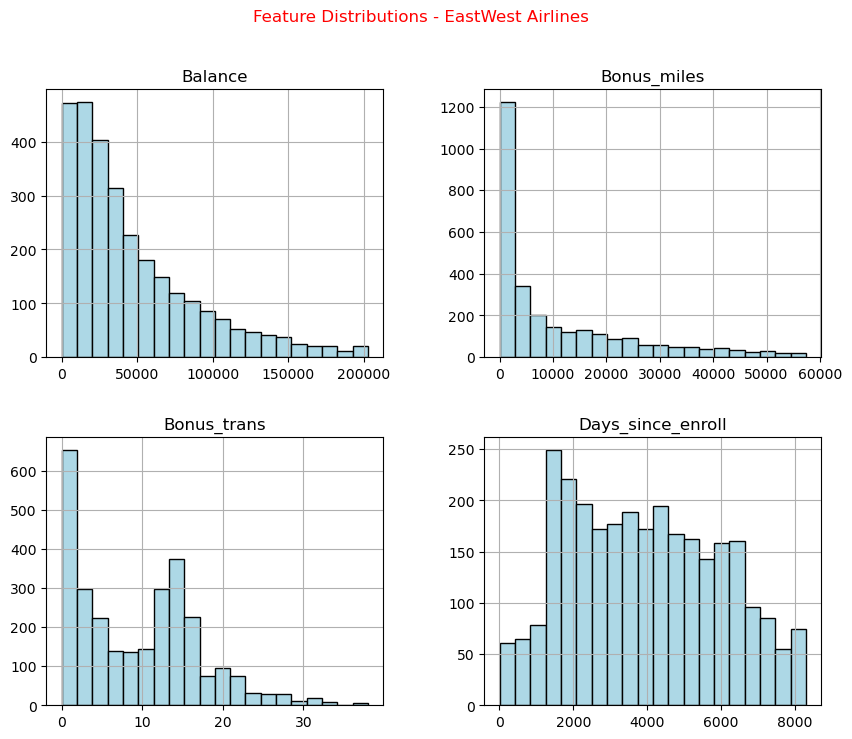

In [72]:
# Visualize distribution of selected numerical features
df[['Balance', 'Bonus_miles', 'Bonus_trans', 'Days_since_enroll']].hist(bins=20, figsize=(10, 8), color='lightblue', edgecolor='black')
plt.suptitle("Feature Distributions - EastWest Airlines",color='red')
plt.show()

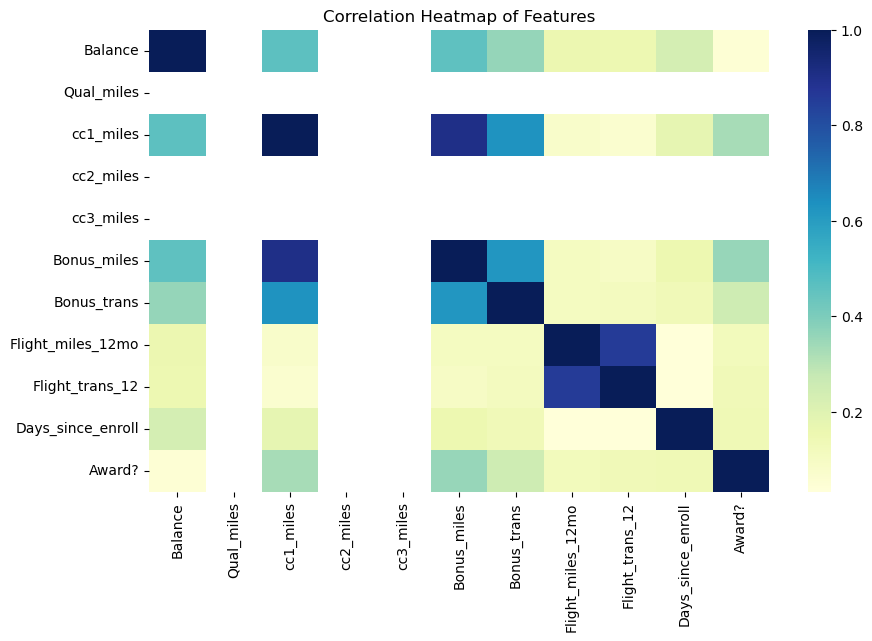

In [73]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()

### K-Means Clustering

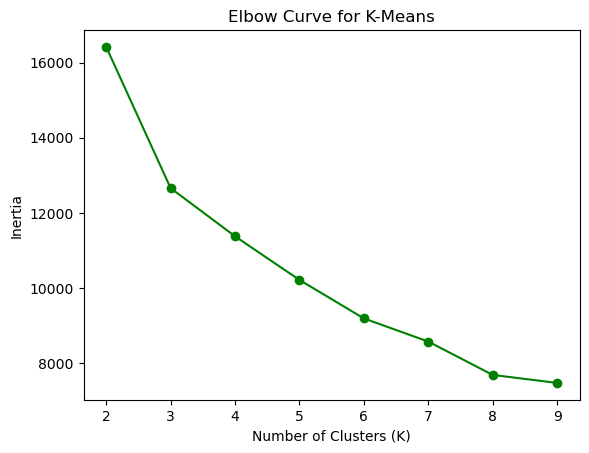

In [75]:
# Elbow method to determine optimal number of clusters
inertia = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o', color='green')
plt.title("Elbow Curve for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [76]:
# From the elbow curve, choose optimal K (for example, K=4)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df['KMeans_Cluster'] = kmeans_labels

In [77]:
# Evaluate K-Means with silhouette score
sil_kmeans = silhouette_score(scaled_data, kmeans_labels)
print(f"K-Means Silhouette Score: {sil_kmeans:.3f}")

K-Means Silhouette Score: 0.230


### DBSCAN Clustering

In [78]:
# Apply DBSCAN with sample parameters (tune eps, min_samples as needed)
dbscan = DBSCAN(eps=1.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)
df['DBSCAN_Cluster'] = dbscan_labels

In [79]:
# Check number of clusters formed
print("\nDBSCAN cluster labels:", np.unique(dbscan_labels))


DBSCAN cluster labels: [-1  0  1  2  3  4  5  6  7  8]


In [80]:
# Evaluate DBSCAN if more than one cluster is found
if len(set(dbscan_labels)) > 1:
    sil_dbscan = silhouette_score(scaled_data, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {sil_dbscan:.3f}")
else:
    print("DBSCAN formed a single cluster (silhouette score not applicable).")


DBSCAN Silhouette Score: 0.252


In [81]:
# Visualization of Clusters (PCA for 2D view)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

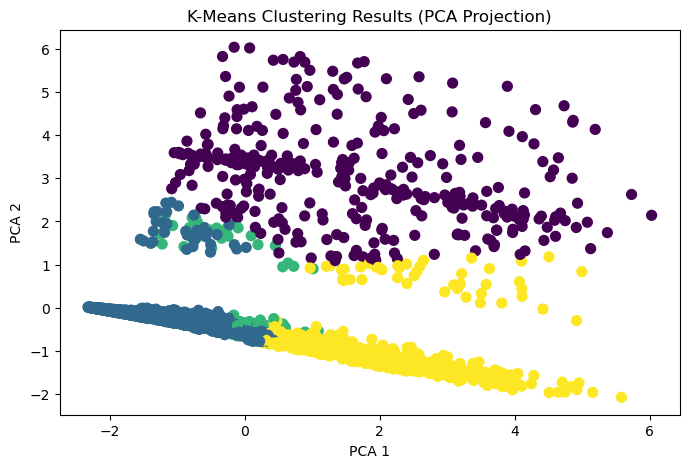

In [82]:
# Plot K-Means Clusters
plt.figure(figsize=(8, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title("K-Means Clustering Results (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

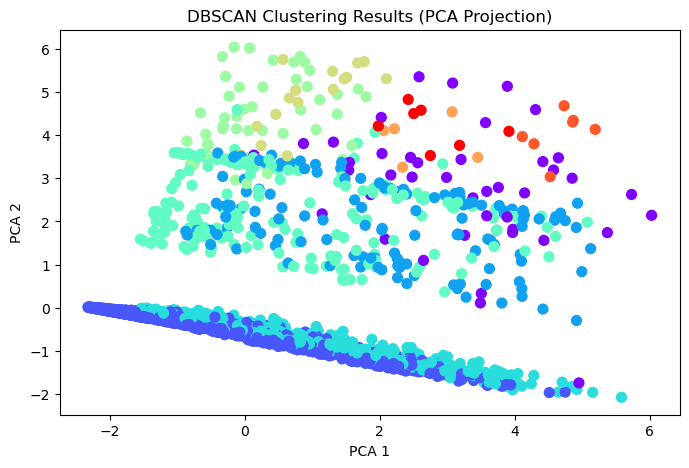

In [83]:
# Plot DBSCAN Clusters
plt.figure(figsize=(8, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=dbscan_labels, cmap='rainbow', s=50)
plt.title("DBSCAN Clustering Results (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [84]:
# Cluster Analysis and Insights
print("\nK-Means Cluster Averages:")
print(df.groupby('KMeans_Cluster').mean())

# Insights:
# Cluster 0: May represent low-balance, less active flyers
# Cluster 1: High balance and active bonus earners (frequent travelers)
# Cluster 2: Moderate engagement
# Cluster 3: Possibly infrequent users or new enrollees

print("\nDBSCAN Cluster Distribution:")
print(df['DBSCAN_Cluster'].value_counts())



K-Means Cluster Averages:
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                              
0               65113.991501         0.0   2.065156        1.0        1.0   
1               25552.377339         0.0   1.092516        1.0        1.0   
2               36146.795071         0.0   1.138781        1.0        1.0   
3               75069.773131         0.0   3.299113        1.0        1.0   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               14463.011331    11.756374         428.084986         1.308782   
1                2772.070686     5.465696           4.810811         0.038462   
2                3479.610895     6.156939           4.203632         0.036316   
3               26368.466413    16.259823           6.510773         0.055767   

                Days_si

                                                     Submitted by: Meghana C Varghese